# Genshin Location NER with CRF

This notebook trains a Conditional Random Field (CRF) model for Genshin Impact location NER using the thesis methodology:

- IOB-tagged training data from `genshin_ner_dataset.tsv`
- Gazetteer augmentation from `genshin_areas.json`
- Evaluation with Precision, Recall, F1-Score, Accuracy, and a Confusion Matrix
- Inference on raw English player queries

It is ordered to work with **Run all** in Google Colab. If the dataset files are not already present, the notebook will prompt for upload.

## Notebook Flow

1. Install dependencies
2. Set file paths and load dataset files
3. Prepare the gazetteer
4. Tokenize and normalize text
5. Build CRF features
6. Parse the IOB dataset and augment with gazetteer data
7. Train and evaluate the CRF model
8. Run inference on example queries

## 1. Install Dependencies

This cell installs the required packages if they are not already available in Colab or Jupyter.

In [252]:
import pkgutil
import subprocess
import sys

packages = {
    "sklearn_crfsuite": "sklearn-crfsuite",
    "nltk": "nltk",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "numpy": "numpy",
}

missing = [pip_name for module_name, pip_name in packages.items() if pkgutil.find_loader(module_name) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed:", ", ".join(missing))
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 2. Set Paths and Load Files

This cell prepares the working directory, output folder, and optional Colab file upload flow.

In [253]:
from pathlib import Path
import sys

IN_COLAB = "google.colab" in sys.modules
BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "genshin_ner_dataset.tsv"
GAZETTEER_PATH = BASE_DIR / "genshin_areas.json"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

if IN_COLAB and (not DATASET_PATH.exists() or not GAZETTEER_PATH.exists()):
    from google.colab import files

    print("Upload `genshin_ner_dataset.tsv` and `genshin_areas.json` to continue.")
    files.upload()

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {DATASET_PATH}")

if not GAZETTEER_PATH.exists():
    raise FileNotFoundError(f"Gazetteer file not found: {GAZETTEER_PATH}")


def preview_text_file(path: Path, max_lines: int = 5) -> list[str]:
    preview = []
    with open(path, "r", encoding="utf-8") as handle:
        for _ in range(max_lines):
            line = handle.readline()
            if not line:
                break
            preview.append(line.rstrip("\n"))
    return preview


def validate_uploaded_dataset_file(path: Path) -> None:
    preview = preview_text_file(path, max_lines=5)
    joined_preview = " ".join(preview).lower()

    if any(marker in joined_preview for marker in ['"cells"', '"metadata"', '"nbformat"']):
        raise ValueError(
            "The uploaded `genshin_ner_dataset.tsv` looks like a Jupyter notebook JSON file, not a token-tag TSV file. "
            "Please re-upload the real dataset file where each line looks like `token<TAB>tag`."
        )

    print("Dataset file preview:")
    for line in preview:
        print(line)


validate_uploaded_dataset_file(DATASET_PATH)

print(f"Dataset: {DATASET_PATH}")
print(f"Gazetteer: {GAZETTEER_PATH}")
print(f"Outputs: {OUTPUT_DIR}")

Dataset file preview:
Does	O
anyone	O
know	O
how	O
to	O
Dataset: d:\Fajrul\Kuliah\Skripsi\Chatbot\genshin_ner_dataset.tsv
Gazetteer: d:\Fajrul\Kuliah\Skripsi\Chatbot\genshin_areas.json
Outputs: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs


## 3. Import Libraries and Define Global Settings

This section loads the Python libraries, model labels, alias map, and shared constants used by the NLP pipeline.

In [254]:
import json
import pickle
import random
import re

import matplotlib.pyplot as plt
import nltk
try:
    from IPython.display import Image, display
except ImportError:
    Image = None

    def display(obj):
        print(obj)
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF, metrics

LABELS = ["O", "B-LOC", "I-LOC"]
LOCATION_CONNECTORS = {"of", "de", "al", "al-", "the"}
ALIAS_MAP = {
    # === MONDSTADT ===
    "mondo": "mondstadt",
    "mond": "mondstadt",
    "mondstat": "mondstadt", # Typo yang sangat sering terjadi
    "dragon spine": "dragonspine",
    "stormterror": "stormterror's lair",
    "dvalin lair": "stormterror's lair",
    "dvalin's lair": "stormterror's lair",
    
    # === LIYUE ===
    "chasm": "the chasm",
    "chasm underground": "the chasm: underground mines",
    "underground mines": "the chasm: underground mines",
    "chasm maw": "the chasm's maw",
    "liyue city": "liyue harbor",
    "chenyu": "chenyu vale: upper vale", # Biasanya player menyebut chenyu merujuk ke area utamanya
    
    # === INAZUMA ===
    "enka": "enkanomiya",
    "watatsumi": "watatsumi island",
    "narukami": "narukami island",
    "seirai": "seirai island",
    "yashiori": "yashiori island",
    "tsurumi": "tsurumi island",
    "narukami shrine": "grand narukami shrine (subarea)",
    "grand narukami shrine": "grand narukami shrine (subarea)",
    
    # === SUMERU ===
    "sumeru desert": "hypostyle desert",
    "hadramaveth": "desert of hadramaveth",
    "king deshret": "the mausoleum of king deshret",
    "mausoleum": "the mausoleum of king deshret",
    "pyramid": "the mausoleum of king deshret", # Sering disebut pyramid di komunitas
    "farakhkert": "realm of farakhkert",
    "oasis": "vourukasha oasis",
    "vanarana": "vanarana (subarea)",
    "old vanarana": "lost nursery",
    
    # === FONTAINE ===
    "fri": "fontaine research institute of kinetic energy engineering region",
    "research institute": "fontaine research institute of kinetic energy engineering region",
    "kinetic institute": "fontaine research institute of kinetic energy engineering region",
    "meropide": "fortress of meropide",
    "prison": "fortress of meropide", # Sering disebut prison/penjara
    "remuria": "sea of bygone eras", # Remuria adalah nama lore dari map ini
    "bygone eras": "sea of bygone eras",
    "court of fontaine": "court of fontaine region",
    
    # === NATLAN ===
    "stadium": "stadium of the sacred flame",
    "scions": "\"scions of the canopy\"",
    "canopy": "\"scions of the canopy\"",
    "echoes": "\"children of echoes\"",
    "springs": "\"people of the springs\"",
    "night wind": "\"masters of the night-wind\"",
    "flower feather": "\"flower-feather clan\"",
    "collective": "\"collective of plenty\"",
    "night kingdom": "night kingdom",
    
    # === NOD-KRAI ===
    "nod krai": "nod-krai",
    "nodkrai": "nod-krai",
    "kuuvahki": "kuuvahki experimental design bureau",
    "design bureau": "kuuvahki experimental design bureau",
    "research institute nod krai": "special territory research institute",
    "special territory": "special territory research institute"
}
_ABBREV_RE = re.compile(r"^[A-Z][a-z]{0,3}\.$")

print("Imports and global settings loaded.")

Imports and global settings loaded.


## 4. Gazetteer Preparation

This section flattens the nested map hierarchy from `genshin_areas.json` into lookup sets for exact location matching.

In [255]:
def normalize_name(name: str) -> str:
    name = name.lower().strip()
    if name.startswith('"') and name.endswith('"'):
        name = name[1:-1]
    name = re.sub(r"\s*\([^)]*\)\s*$", "", name)
    return name.strip()


def flatten_gazetteer(data: dict) -> set[str]:
    names: set[str] = set()
    for region_name, region_data in data.items():
        names.add(normalize_name(region_name))
        if not isinstance(region_data, dict):
            continue
        for area_name, area_data in region_data.get("areas", {}).items():
            names.add(normalize_name(area_name))
            if isinstance(area_data, dict):
                for sub_area in area_data.get("sub_areas", []):
                    cleaned = normalize_name(sub_area)
                    if cleaned:
                        names.add(cleaned)
    names.discard("")
    return names


def build_token_set(names: set[str]) -> set[str]:
    tokens: set[str] = set()
    for name in names:
        for word in name.split():
            cleaned = word.strip(':.,;"\'()')
            if cleaned and len(cleaned) > 1:
                tokens.add(cleaned)
    return tokens


def load_gazetteer(json_path: str) -> tuple[set[str], set[str]]:
    with open(json_path, "r", encoding="utf-8") as handle:
        data = json.load(handle)

    names = flatten_gazetteer(data)
    for expansion in ALIAS_MAP.values():
        names.add(normalize_name(expansion))

    return names, build_token_set(names)

with open(GAZETTEER_PATH, "r", encoding="utf-8") as handle:
    gazetteer_raw = json.load(handle)

sample_region_name = next(iter(gazetteer_raw))
sample_region = gazetteer_raw[sample_region_name]
gazetteer_names, gazetteer_tokens = load_gazetteer(str(GAZETTEER_PATH))

print("Gazetteer before flattening:")
print({
    sample_region_name: {
        "type": sample_region.get("type"),
        "sample_areas": list(sample_region.get("areas", {}).keys())[:3],
    }
})
print("\nFlattened gazetteer sample (first 5 names):")
print(sorted(gazetteer_names)[:5])
print("\nFlattened gazetteer token sample (first 5 tokens):")
print(sorted(gazetteer_tokens)[:5])

Gazetteer before flattening:
{'Mondstadt': {'type': 'Region', 'sample_areas': ['Brightcrown Mountains', 'Galesong Hill', 'Starfell Valley']}}

Flattened gazetteer sample (first 5 names):
['a lonely place', 'a very bright place', 'a very warm place', 'aaru village', 'abdju pit']

Flattened gazetteer token sample (first 5 tokens):
['aaru', 'abdju', 'ad-hoc', "adeptus's", 'al-azif']


## 5. Tokenization and Text Normalization

This section handles special location-name cases such as quotes, parentheses, apostrophes, colons, hyphens, and `Mt.` abbreviations.

In [256]:
def tokenize_locations(text: str) -> list[str]:
    for old, new in (("\u201c", '"'), ("\u201d", '"'), ("\u2018", "'"), ("\u2019", "'")):
        text = text.replace(old, new)

    tokens: list[str] = []
    for token in text.split():
        while len(token) > 1 and token[0] == '"' and token[-1] == '"':
            token = token[1:-1]
        token = token.strip('"')

        if token.startswith("(") and token.endswith(")"):
            continue
        token = re.sub(r"\([^)]*\)$", "", token)

        if not _ABBREV_RE.match(token):
            token = token.rstrip("?!,;.")

        if token:
            tokens.append(token)

    merged_tokens: list[str] = []
    idx = 0
    while idx < len(tokens):
        if idx + 1 < len(tokens) and tokens[idx] == "Mt." and tokens[idx + 1] and tokens[idx + 1][0].isalpha():
            merged_tokens.append(f"{tokens[idx]} {tokens[idx + 1]}")
            idx += 2
            continue
        merged_tokens.append(tokens[idx])
        idx += 1

    return merged_tokens


def ensure_pos_tagger() -> None:
    try:
        nltk.data.find("taggers/averaged_perceptron_tagger_eng")
    except LookupError:
        try:
            nltk.download("averaged_perceptron_tagger_eng", quiet=True)
        except Exception:
            nltk.download("averaged_perceptron_tagger", quiet=True)


def get_pos_tags(tokens: list[str]) -> list[str]:
    ensure_pos_tagger()
    return [tag for _, tag in nltk.pos_tag(tokens)]


def normalize_token(token: str) -> str:
    return normalize_name(token).strip(':.,;!?"')


def build_sentence_lookup(tokens: list[str]) -> set[str]:
    cleaned = [normalize_token(token) for token in tokens if normalize_token(token)]
    phrases: set[str] = set()
    for start in range(len(cleaned)):
        current = []
        for end in range(start, min(len(cleaned), start + 5)):
            current.append(cleaned[end])
            phrases.add(" ".join(current))
    return phrases

sample_text = '"Children of Echoes" near Vanarana (Subarea) and Mt. Aocang in The Chasm: Underground Mines?'
sample_tokens = tokenize_locations(sample_text)

print("Tokenization before:")
print(sample_text)
print("\nTokenization after:")
print(sample_tokens)
print("\nNormalized token preview:")
print([(token, normalize_token(token)) for token in sample_tokens[:5]])

Tokenization before:
"Children of Echoes" near Vanarana (Subarea) and Mt. Aocang in The Chasm: Underground Mines?

Tokenization after:
['Children', 'of', 'Echoes', 'near', 'Vanarana', 'and', 'Mt. Aocang', 'in', 'The', 'Chasm:', 'Underground', 'Mines']

Normalized token preview:
[('Children', 'children'), ('of', 'of'), ('Echoes', 'echoes'), ('near', 'near'), ('Vanarana', 'vanarana')]


## 6. Feature Engineering

This section creates the CRF feature dictionary, including lexical, POS-tag, context-window, alias, and gazetteer features.

In [257]:
def word2features(
    sentence: list[str],
    pos_tags: list[str],
    index: int,
    gazetteer_names: set[str],
    gazetteer_tokens: set[str],
    sentence_lookup: set[str],
) -> dict[str, object]:
    word = sentence[index]
    normalized = normalize_token(word)
    postag = pos_tags[index]

    in_token_set = normalized in gazetteer_tokens
    in_full_name = normalized in gazetteer_names
    in_sentence_gazetteer = any(
        phrase in gazetteer_names for phrase in sentence_lookup if normalized and normalized in phrase.split()
    )

    features = {
        "bias": 1.0,
        "word": word,
        "word.lower()": word.lower(),
        "word.normalized": normalized,
        "word.isupper()": word.isupper(),
        "word.istitle()": word.istitle(),
        "word.isdigit()": word.isdigit(),
        "word.has_hyphen": "-" in word,
        "word.has_apostrophe": "'" in word,
        "word.has_colon": ":" in word,
        "word.prefix2": normalized[:2],
        "word.prefix3": normalized[:3],
        "word.suffix2": normalized[-2:],
        "word.suffix3": normalized[-3:],
        "postag": postag,
        "postag[:2]": postag[:2],
        "is_sentence_start": index == 0,
        "is_sentence_end": index == len(sentence) - 1,
        "is_location_connector": normalized in LOCATION_CONNECTORS,
        "matches_alias": normalized in ALIAS_MAP,
        "in_alias_expansion": any(normalized in expansion.split() for expansion in ALIAS_MAP.values()),
        "is_in_genshin_map": in_token_set or in_full_name,
        "gazetteer_word_overlap": in_token_set,
        "gazetteer_phrase_overlap": in_sentence_gazetteer,
    }

    if index > 0:
        prev_word = sentence[index - 1]
        prev_norm = normalize_token(prev_word)
        features.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:word.normalized": prev_norm,
            "-1:postag": pos_tags[index - 1],
            "-1:postag[:2]": pos_tags[index - 1][:2],
            "-1:is_connector": prev_norm in LOCATION_CONNECTORS,
        })
    else:
        features["BOS"] = True

    if index < len(sentence) - 1:
        next_word = sentence[index + 1]
        next_norm = normalize_token(next_word)
        features.update({
            "+1:word.lower()": next_word.lower(),
            "+1:word.normalized": next_norm,
            "+1:postag": pos_tags[index + 1],
            "+1:postag[:2]": pos_tags[index + 1][:2],
            "+1:is_connector": next_norm in LOCATION_CONNECTORS,
        })
    else:
        features["EOS"] = True

    if index > 1:
        features["-2:word.lower()"] = sentence[index - 2].lower()
        features["-2:postag"] = pos_tags[index - 2]

    if index < len(sentence) - 2:
        features["+2:word.lower()"] = sentence[index + 2].lower()
        features["+2:postag"] = pos_tags[index + 2]

    return features


def sent2features(sentence: list[str], gazetteer_names: set[str], gazetteer_tokens: set[str]) -> list[dict[str, object]]:
    pos_tags = get_pos_tags(sentence)
    sentence_lookup = build_sentence_lookup(sentence)
    return [
        word2features(sentence, pos_tags, idx, gazetteer_names, gazetteer_tokens, sentence_lookup)
        for idx in range(len(sentence))
    ]

feature_sentence = tokenize_locations("How do I enter Mondstadt through Stone Gate?")
feature_index = feature_sentence.index("Mondstadt")
feature_output = sent2features(feature_sentence, gazetteer_names, gazetteer_tokens)

print("Feature engineering before:")
print(feature_sentence)
print("\nFeature engineering target token:")
print(feature_sentence[feature_index])
print("\nFeature engineering after (selected token feature dictionary):")
print(feature_output[feature_index])

Feature engineering before:
['How', 'do', 'I', 'enter', 'Mondstadt', 'through', 'Stone', 'Gate']

Feature engineering target token:
Mondstadt

Feature engineering after (selected token feature dictionary):
{'bias': 1.0, 'word': 'Mondstadt', 'word.lower()': 'mondstadt', 'word.normalized': 'mondstadt', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, 'word.has_hyphen': False, 'word.has_apostrophe': False, 'word.has_colon': False, 'word.prefix2': 'mo', 'word.prefix3': 'mon', 'word.suffix2': 'dt', 'word.suffix3': 'adt', 'postag': 'NNP', 'postag[:2]': 'NN', 'is_sentence_start': False, 'is_sentence_end': False, 'is_location_connector': False, 'matches_alias': False, 'in_alias_expansion': True, 'is_in_genshin_map': True, 'gazetteer_word_overlap': True, 'gazetteer_phrase_overlap': True, '-1:word.lower()': 'enter', '-1:word.normalized': 'enter', '-1:postag': 'VBP', '-1:postag[:2]': 'VB', '-1:is_connector': False, '+1:word.lower()': 'through', '+1:word.normalized': 'thro

## 7. Dataset Parsing and Gazetteer Augmentation

This section reads the IOB-format TSV dataset and optionally adds lightweight gazetteer-based training examples.

In [258]:
def parse_tsv_dataset(dataset_path: str) -> list[tuple[list[str], list[str]]]:
    sentences = []
    tokens = []
    tags = []
    skipped_lines = []

    with open(dataset_path, "r", encoding="utf-8") as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.strip()
            if not line:
                if tokens:
                    sentences.append((tokens, tags))
                    tokens, tags = [], []
                continue

            if "\t" in line:
                parts = line.split("\t", 1)
            else:
                parts = line.rsplit(None, 1)

            if len(parts) != 2:
                skipped_lines.append((line_number, line))
                continue

            token, tag = parts[0].strip(), parts[1].strip()
            if tag not in {"O", "B-LOC", "I-LOC"}:
                skipped_lines.append((line_number, line))
                continue

            tokens.append(token)
            tags.append(tag)

    if tokens:
        sentences.append((tokens, tags))

    if skipped_lines:
        print("Skipped malformed dataset lines:", skipped_lines[:5])

    return sentences


def extract_first_location_span(tags: list[str]) -> tuple[int, int] | None:
    start_index = None
    end_index = None

    for index, tag in enumerate(tags):
        if tag == "B-LOC":
            if start_index is not None:
                break
            start_index = index
            end_index = index + 1
        elif tag == "I-LOC" and start_index is not None:
            end_index = index + 1
        elif start_index is not None:
            break

    if start_index is None or end_index is None:
        return None
    return start_index, end_index


def build_augmented_sentence(template_tokens: list[str], template_tags: list[str], location_name: str) -> tuple[list[str], list[str]] | None:
    location_span = extract_first_location_span(template_tags)
    if location_span is None:
        return None

    location_tokens = tokenize_locations(location_name)
    if not location_tokens:
        return None

    start_index, end_index = location_span
    augmented_tokens = template_tokens[:start_index] + location_tokens + template_tokens[end_index:]
    augmented_tags = template_tags[:start_index] + ["B-LOC"] + ["I-LOC"] * (len(location_tokens) - 1) + template_tags[end_index:]
    return augmented_tokens, augmented_tags


def augment_with_gazetteer(
    sentences,
    gazetteer_names,
    max_examples: int = 10000,
    random_state: int = 42,
    templates_per_area: int = 3,
):
    rng = random.Random(random_state)
    candidates = [
        name for name in gazetteer_names
        if name and len(name.split()) <= 6 and name not in ALIAS_MAP
    ]
    rng.shuffle(candidates)

    sentence_templates = [
        (tokens, tags)
        for tokens, tags in sentences
        if extract_first_location_span(tags) is not None
    ]
    rng.shuffle(sentence_templates)

    augmented = list(sentences)
    seen_augmented_sentences = {tuple(tokens) for tokens, _ in sentences}
    added_examples = 0
    for name in candidates:
        template_cycle = list(sentence_templates)
        rng.shuffle(template_cycle)
        used_templates_for_area = 0

        for template_tokens, template_tags in template_cycle:
            if added_examples >= max_examples or used_templates_for_area >= templates_per_area:
                break

            augmented_sentence = build_augmented_sentence(template_tokens, template_tags, name)
            if augmented_sentence is None:
                continue

            augmented_tokens, augmented_tags = augmented_sentence
            sentence_key = tuple(augmented_tokens)
            if sentence_key in seen_augmented_sentences:
                continue

            augmented.append((augmented_tokens, augmented_tags))
            seen_augmented_sentences.add(sentence_key)
            added_examples += 1
            used_templates_for_area += 1

        if added_examples >= max_examples:
            return augmented
    return augmented


def build_feature_matrices(sentences, gazetteer_names, gazetteer_tokens):
    X = [sent2features(tokens, gazetteer_names, gazetteer_tokens) for tokens, _ in sentences]
    y = [tags for _, tags in sentences]
    return X, y

dataset_sentences = parse_tsv_dataset(str(DATASET_PATH))
if not dataset_sentences:
    raise ValueError(
        "No valid training sentences were parsed from `genshin_ner_dataset.tsv`. "
        "Check that the uploaded file is the real token-tag dataset and not another file."
    )

augmented_preview = augment_with_gazetteer(dataset_sentences, gazetteer_names, max_examples=3, random_state=42)

print("Dataset before augmentation (sentence count):", len(dataset_sentences))
print("First parsed sentence:")
print(dataset_sentences[0])
print("\nDataset after augmentation preview (sentence count):", len(augmented_preview))
print("Last 3 augmented sentences:")
for example in augmented_preview[-3:]:
    print(example)

Dataset before augmentation (sentence count): 21
First parsed sentence:
(['Does', 'anyone', 'know', 'how', 'to', 'enter', 'the', 'west', 'wing', 'of', 'the', 'fatui', 'base'], ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'I-LOC', 'I-LOC', 'I-LOC'])

Dataset after augmentation preview (sentence count): 24
Last 3 augmented sentences:
(['Do', 'you', 'guys', 'remember', 'how', 'to', 'enter', 'the', "kunado's", 'locus'], ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC'])
(['how', 'to', 'enter', "kunado's", 'locus'], ['O', 'O', 'O', 'B-LOC', 'I-LOC'])
(['Can', 'i', 'access', 'and', 'almost', 'fully', 'explore', "kunado's", 'locus', 'without', 'a', 'quest', 'or', 'is', 'a', 'quest', 'required'], ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'])


In [259]:
full_augmented = augment_with_gazetteer(dataset_sentences, gazetteer_names, random_state=42)
all_keys = [tuple(tokens) for tokens, _ in full_augmented]
unique_keys = set(all_keys)

duplicate_count = len(all_keys) - len(unique_keys)
print(f"Total kalimat (asli + augmentasi): {len(all_keys)}")
print(f"Kalimat unik: {len(unique_keys)}")
print(f"Duplikat: {duplicate_count}")

if duplicate_count > 0:
    from collections import Counter
    counts = Counter(all_keys)
    duplicates = [(key, cnt) for key, cnt in counts.items() if cnt > 1]
    print(f"\nContoh kalimat duplikat (maks 5):")
    for tokens, cnt in duplicates[:5]:
        print(f"  [{cnt}x] {' '.join(tokens)}")
else:
    print("\nTidak ada kalimat duplikat — augmentasi bersih.")

Total kalimat (asli + augmentasi): 1035
Kalimat unik: 1035
Duplikat: 0

Tidak ada kalimat duplikat — augmentasi bersih.


## 8. CRF Training, Evaluation, and Training Pipeline

`train_crf`, `evaluate`, confusion matrix export, `save_model`, and `train_pipeline`. Run this cell first in this section (resolver cells below depend on these utilities when you train).


In [ ]:
def train_crf(X_train, y_train, c1: float = 0.1, c2: float = 0.1, max_iterations: int = 200) -> CRF:
    model = CRF(
        algorithm="lbfgs",
        c1=c1,
        c2=c2,
        max_iterations=max_iterations,
        all_possible_transitions=True,
    )
    model.fit(X_train, y_train)
    return model


def flatten_labels(nested: list[list[str]]) -> list[str]:
    return [label for sentence in nested for label in sentence]


def evaluate(y_true, y_pred, output_dir: Path, figure_name: str = "confusion_matrix_ner.png"):
    report = metrics.flat_classification_report(y_true, y_pred, labels=["B-LOC", "I-LOC"], digits=4)
    flat_true = flatten_labels(y_true)
    flat_pred = flatten_labels(y_pred)
    accuracy = accuracy_score(flat_true, flat_pred)

    matrix = confusion_matrix(flat_true, flat_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 5))
    display_cm = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=LABELS)
    display_cm.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("CRF NER Confusion Matrix")
    fig.tight_layout()

    figure_path = output_dir / figure_name
    fig.savefig(figure_path, dpi=200)
    plt.close(fig)

    return {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": matrix,
        "confusion_matrix_path": figure_path,
    }


def save_model(model: CRF, model_path: Path) -> None:
    with open(model_path, "wb") as handle:
        pickle.dump(model, handle)


def train_pipeline(dataset_path: Path, gazetteer_path: Path, output_dir: Path, augment_from_gazetteer: bool = True, random_state: int = 42):
    gazetteer_names, gazetteer_tokens = load_gazetteer(str(gazetteer_path))
    sentences_before_augmentation = parse_tsv_dataset(str(dataset_path))
    print("Training pipeline - dataset size before augmentation:", len(sentences_before_augmentation))

    sentences = sentences_before_augmentation
    if augment_from_gazetteer:
        sentences = augment_with_gazetteer(sentences, gazetteer_names, random_state=random_state)
        print("Training pipeline - dataset size after augmentation:", len(sentences))

    train_sentences, test_sentences = train_test_split(
        sentences,
        test_size=0.2,
        random_state=random_state,
        shuffle=True,
    )
    print("Training pipeline - train/test split:", len(train_sentences), len(test_sentences))

    X_train, y_train = build_feature_matrices(train_sentences, gazetteer_names, gazetteer_tokens)
    X_test, y_test = build_feature_matrices(test_sentences, gazetteer_names, gazetteer_tokens)

    print("Training pipeline - first train sentence tokens:")
    print(train_sentences[0][0])
    print("Training pipeline - first train sentence labels:")
    print(train_sentences[0][1])

    model = train_crf(X_train, y_train)
    y_pred = model.predict(X_test)
    evaluation = evaluate(y_test, y_pred, output_dir=output_dir)

    model_path = output_dir / "genshin_location_crf.pkl"
    save_model(model, model_path)

    return {
        "model": model,
        "model_path": model_path,
        "gazetteer_names": gazetteer_names,
        "gazetteer_tokens": gazetteer_tokens,
        "evaluation": evaluation,
    }

print("CRF training, evaluation, save_model, and train_pipeline loaded.")


CRF training, evaluation, save_model, and train_pipeline loaded.


## 8A. Span Extraction for Inference

`extract_crf_spans` and `extract_exact_gazetteer_mentions` for hybrid decoding.


In [261]:
def extract_crf_spans(tokens: list[str], predicted_tags: list[str]) -> list[str]:
    spans = []
    current_span = []
    for token, tag in zip(tokens, predicted_tags):
        if tag == "B-LOC":
            if current_span:
                spans.append(" ".join(current_span))
            current_span = [token]
        elif tag == "I-LOC":
            if current_span:
                current_span.append(token)
            else:
                current_span = [token]
        else:
            if current_span:
                spans.append(" ".join(current_span))
                current_span = []

    if current_span:
        spans.append(" ".join(current_span))

    deduplicated_spans = []
    for span in spans:
        normalized_span = normalize_name(span)
        if normalized_span and normalized_span not in deduplicated_spans:
            deduplicated_spans.append(normalized_span)

    return deduplicated_spans


def extract_exact_gazetteer_mentions(tokens: list[str], gazetteer_names: set[str], max_window: int = 8) -> list[str]:
    normalized_tokens = [normalize_name(token) for token in tokens]
    exact_mentions = []
    index = 0

    while index < len(normalized_tokens):
        best_match = None
        best_end = index
        upper_bound = min(len(normalized_tokens), index + max_window)

        for end in range(upper_bound, index, -1):
            candidate_tokens = [token for token in normalized_tokens[index:end] if token]
            candidate = " ".join(candidate_tokens)
            if candidate in gazetteer_names:
                best_match = candidate
                best_end = end
                break

        if best_match is not None:
            if best_match not in exact_mentions:
                exact_mentions.append(best_match)
            index = best_end
        else:
            index += 1

    return exact_mentions

print("Span extraction helpers loaded.")


Span extraction helpers loaded.


## 8B. Resolver — Overlap and Entity Builders

Resolver constants, `tokenise_for_overlap`, overlap scoring, `build_exact_entity`, `build_alias_entity`.


In [262]:
RESOLVER_STOPWORDS = {
    "the", "in", "of", "to", "and", "a", "an", "on", "at", "for", "near", "through"
}
NON_LOCATION_QUERY_WORDS = {
    "access", "also", "boat", "bro", "can", "cant", "can't", "carry",
    "difference", "do", "does", "doesn't", "don't", "done", "enter", "fast",
    "find", "get", "go", "guide", "hard", "harder", "hate", "help", "how",
    "inside", "is", "isn't", "it", "it's", "just", "know", "make", "man",
    "need", "pls", "please", "quest", "reach", "route", "someone", "take",
    "than", "that", "there", "tf", "unlock", "want", "way", "what", "where",
    "won't",
}
GENERIC_GAZETTEER_TOKENS = {
    "camp", "camps", "cave", "city", "east", "gate", "inn", "island",
    "north", "port", "ruins", "site", "south", "village", "west",
}
OVERLAP_MIN_SCORE = 0.5
FUZZY_OVERLAP_MIN_SCORE = 0.45
RAW_RESOLVED_NAME_FLOOR = 0.5
AMBIGUITY_MARGIN = 0.1
MAX_RESOLVER_CANDIDATES = 5
ALIAS_CONFIDENCE = 0.98
FUZZY_CONFIDENCE_PENALTY = 0.08
MIN_FUZZY_TOKEN_LENGTH = 4

def tokenise_for_overlap(text: str) -> list[str]:
    normalized_text = normalize_name(text)
    rough_tokens = re.split(r"[\s:\-]+", normalized_text)
    cleaned_tokens = []
    for token in rough_tokens:
        cleaned = normalize_token(token)
        if cleaned and cleaned not in RESOLVER_STOPWORDS:
            cleaned_tokens.append(cleaned)
    return cleaned_tokens


def explain_candidate_reason(overlap_count: int, overlap_ratio: float, overlap_tokens: list[str], method: str) -> str:
    if method == "alias":
        return "Matched curated alias entry."
    if method == "exact":
        return "Matched exact canonical gazetteer phrase."
    if overlap_count == 0:
        return "No meaningful token overlap."
    return f"Matched {overlap_count} token(s): {overlap_tokens} with overlap ratio {overlap_ratio:.3f}."


def score_overlap_candidate(raw_span: str, candidate_name: str) -> dict[str, object]:
    raw_tokens = set(tokenise_for_overlap(raw_span))
    candidate_tokens = set(tokenise_for_overlap(candidate_name))
    overlap_tokens = sorted(raw_tokens & candidate_tokens)
    overlap_count = len(overlap_tokens)
    overlap_ratio = overlap_count / len(raw_tokens) if raw_tokens else 0.0

    return {
        "name": candidate_name,
        "score": round(overlap_ratio, 3),
        "overlap_count": overlap_count,
        "overlap_ratio": round(overlap_ratio, 3),
        "overlap_tokens": overlap_tokens,
        "candidate_token_count": len(candidate_tokens),
        "reason": explain_candidate_reason(overlap_count, overlap_ratio, overlap_tokens, "overlap"),
    }


def rank_overlap_candidates(raw_span: str, gazetteer_names: set[str], max_candidates: int = MAX_RESOLVER_CANDIDATES) -> list[dict[str, object]]:
    scored_candidates = []
    for candidate_name in gazetteer_names:
        candidate_score = score_overlap_candidate(raw_span, candidate_name)
        if candidate_score["overlap_count"] > 0:
            scored_candidates.append(candidate_score)

    scored_candidates.sort(
        key=lambda item: (
            item["overlap_count"],
            item["overlap_ratio"],
            -item["candidate_token_count"],
            -len(item["name"]),
        ),
        reverse=True,
    )
    return scored_candidates[:max_candidates]


def build_exact_entity(match_name: str) -> dict[str, object]:
    return {
        "raw_span": match_name,
        "resolved_name": match_name,
        "method": "exact",
        "confidence": 1.0,
        "ambiguous": False,
        "candidates": [{"name": match_name, "score": 1.0, "reason": explain_candidate_reason(0, 1.0, [], "exact")}],
        "fuzzy_corrections": [],
    }


def build_alias_entity(raw_span: str, resolved_name: str) -> dict[str, object]:
    return {
        "raw_span": raw_span,
        "resolved_name": resolved_name,
        "method": "alias",
        "confidence": ALIAS_CONFIDENCE,
        "ambiguous": False,
        "candidates": [{"name": resolved_name, "score": ALIAS_CONFIDENCE, "reason": explain_candidate_reason(0, ALIAS_CONFIDENCE, [], "alias")}],
        "fuzzy_corrections": [],
    }
print("Resolver overlap scoring and entity builders loaded.")


Resolver overlap scoring and entity builders loaded.


## 8C. Resolver — Fuzzy Correction and Fallback Spans

Edit distance helpers, gated fuzzy correction, alias n-grams, `collect_fallback_token_spans`.


In [263]:
def edit_distance(left: str, right: str) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)

    previous_row = list(range(len(right) + 1))
    for left_index, left_char in enumerate(left, start=1):
        current_row = [left_index]
        for right_index, right_char in enumerate(right, start=1):
            insert_cost = current_row[right_index - 1] + 1
            delete_cost = previous_row[right_index] + 1
            replace_cost = previous_row[right_index - 1] + (left_char != right_char)
            current_row.append(min(insert_cost, delete_cost, replace_cost))
        previous_row = current_row
    return previous_row[-1]


def get_max_edit_distance(token: str) -> int:
    if len(token) <= 3:
        return 1
    if len(token) <= 9:
        return 2
    return 2


def get_common_prefix_length(left: str, right: str) -> int:
    shared = 0
    for left_char, right_char in zip(left, right):
        if left_char != right_char:
            break
        shared += 1
    return shared


def has_strong_gazetteer_affinity(token: str, gazetteer_tokens: set[str]) -> bool:
    normalized_token = normalize_token(token)
    if not normalized_token:
        return False
    if normalized_token in gazetteer_tokens or normalized_token in ALIAS_MAP:
        return True

    for candidate in gazetteer_tokens:
        if not candidate or candidate[0] != normalized_token[0]:
            continue
        if get_common_prefix_length(normalized_token, candidate) >= 2:
            return True
    return False


def is_location_like_token(token: str, postag: str, gazetteer_tokens: set[str]) -> bool:
    normalized_token = normalize_token(token)
    if not normalized_token or normalized_token in NON_LOCATION_QUERY_WORDS:
        return False
    if has_strong_gazetteer_affinity(normalized_token, gazetteer_tokens):
        return True
    if token.istitle():
        return True
    return postag.startswith("NN")


def build_allowed_fuzzy_tokens(tokens: list[str], predicted_tags: list[str], features: list[dict[str, object]], gazetteer_tokens: set[str]) -> set[str]:
    allowed_tokens = set()
    for token, tag, feature_row in zip(tokens, predicted_tags, features):
        normalized_token = normalize_token(token)
        if not normalized_token:
            continue
        if tag != "O" or is_location_like_token(token, feature_row.get("postag", ""), gazetteer_tokens):
            allowed_tokens.add(normalized_token)
    return allowed_tokens


def find_best_token_correction(token: str, vocabulary: set[str], allowed_tokens: set[str] | None = None) -> dict[str, object] | None:
    normalized_token = normalize_token(token)
    if len(normalized_token) < MIN_FUZZY_TOKEN_LENGTH or normalized_token in RESOLVER_STOPWORDS:
        return None
    if normalized_token in NON_LOCATION_QUERY_WORDS:
        return None
    if allowed_tokens is not None and normalized_token not in allowed_tokens:
        return None

    best_match = None
    best_distance = None
    for candidate in vocabulary:
        if abs(len(candidate) - len(normalized_token)) > get_max_edit_distance(normalized_token):
            continue
        distance = edit_distance(normalized_token, candidate)
        if distance > get_max_edit_distance(normalized_token):
            continue

        if best_match is None or distance < best_distance or (distance == best_distance and len(candidate) < len(best_match)):
            best_match = candidate
            best_distance = distance

    if best_match is None or best_match == normalized_token:
        return None

    return {
        "original": normalized_token,
        "corrected": best_match,
        "distance": best_distance,
        "reason": f"Corrected token '{normalized_token}' to '{best_match}' with edit distance {best_distance}.",
    }


def apply_fuzzy_token_corrections(raw_span: str, gazetteer_tokens: set[str], allowed_tokens: set[str] | None = None) -> tuple[str, list[dict[str, object]]]:
    span_tokens = tokenise_for_overlap(raw_span)
    corrected_tokens = []
    corrections = []

    for token in span_tokens:
        correction = find_best_token_correction(token, gazetteer_tokens, allowed_tokens=allowed_tokens)
        if correction is not None:
            corrected_tokens.append(correction["corrected"])
            corrections.append(correction)
        else:
            corrected_tokens.append(token)

    corrected_span = " ".join(corrected_tokens)
    return corrected_span, corrections


def generate_alias_ngrams(tokens: list[str], max_n: int = 4) -> list[str]:
    normalized_tokens = [normalize_name(token) for token in tokens]
    alias_ngrams = []
    for start in range(len(normalized_tokens)):
        current_tokens = []
        for end in range(start, min(len(normalized_tokens), start + max_n)):
            token = normalized_tokens[end]
            if not token:
                continue
            current_tokens.append(token)
            candidate = " ".join(current_tokens)
            if candidate and candidate not in alias_ngrams:
                alias_ngrams.append(candidate)
    return alias_ngrams


def detect_alias_matches(tokens: list[str], gazetteer_names: set[str]) -> list[dict[str, object]]:
    alias_entities = []
    for alias_candidate in generate_alias_ngrams(tokens):
        if alias_candidate not in ALIAS_MAP:
            continue

        alias_resolved_name = normalize_name(ALIAS_MAP[alias_candidate])
        if alias_candidate in gazetteer_names and alias_resolved_name != alias_candidate:
            continue

        alias_entity = build_alias_entity(alias_candidate, alias_resolved_name)
        overlap_candidates = rank_overlap_candidates(alias_candidate, gazetteer_names)
        if (
            len(tokenise_for_overlap(alias_candidate)) == 1
            and len(overlap_candidates) > 1
            and abs(overlap_candidates[0]["score"] - overlap_candidates[1]["score"]) <= AMBIGUITY_MARGIN
        ):
            alias_entity["ambiguous"] = True
            alias_entity["candidates"] = overlap_candidates
        alias_entities.append(alias_entity)
    return alias_entities


def collect_fallback_token_spans(tokens: list[str], predicted_tags: list[str], features: list[dict[str, object]], gazetteer_tokens: set[str], allowed_fuzzy_tokens: set[str]) -> list[str]:
    fallback_spans = []

    normalized_tokens = [normalize_name(token) for token in tokens]
    for start in range(len(tokens)):
        if predicted_tags[start] != "O":
            continue
        alias_parts = []
        for end in range(start, min(len(tokens), start + 4)):
            if predicted_tags[end] != "O":
                break
            token = normalized_tokens[end]
            if not token:
                continue
            alias_parts.append(token)
            alias_candidate = " ".join(alias_parts)
            if alias_candidate in ALIAS_MAP and alias_candidate not in fallback_spans:
                fallback_spans.append(alias_candidate)

    for token, tag, feature_row in zip(tokens, predicted_tags, features):
        normalized_token = normalize_token(token)
        if tag != "O":
            continue
        if normalized_token in ALIAS_MAP:
            if normalized_token not in fallback_spans:
                fallback_spans.append(normalized_token)
            continue
        if len(normalized_token) < MIN_FUZZY_TOKEN_LENGTH or normalized_token in RESOLVER_STOPWORDS:
            continue
        if not is_location_like_token(token, feature_row.get("postag", ""), gazetteer_tokens):
            continue
        if normalized_token in gazetteer_tokens or find_best_token_correction(normalized_token, gazetteer_tokens, allowed_tokens=allowed_fuzzy_tokens):
            if normalized_token not in fallback_spans:
                fallback_spans.append(normalized_token)
    return fallback_spans

print("Resolver fuzzy correction and alias detection loaded.")


Resolver fuzzy correction and alias detection loaded.


## 8D. Resolver — Resolution, Merge, and Query API

`resolve_span_to_canonical`, merge/dedup, `resolve_query_locations`, `extract_locations`.


In [264]:
def build_overlap_entity(raw_span: str, overlap_candidates: list[dict[str, object]], method: str, confidence: float, ambiguous: bool, fuzzy_corrections: list[dict[str, object]]) -> dict[str, object]:
    return {
        "raw_span": normalize_name(raw_span),
        "resolved_name": overlap_candidates[0]["name"],
        "method": method,
        "confidence": round(confidence, 3),
        "ambiguous": ambiguous,
        "candidates": overlap_candidates,
        "fuzzy_corrections": fuzzy_corrections,
    }


def resolve_span_to_canonical(raw_span: str, gazetteer_names: set[str], gazetteer_tokens: set[str], allowed_fuzzy_tokens: set[str] | None = None) -> dict[str, object]:
    normalized_span = normalize_name(raw_span)

    if normalized_span in gazetteer_names:
        return build_exact_entity(normalized_span)

    if normalized_span in ALIAS_MAP:
        alias_entity = build_alias_entity(normalized_span, normalize_name(ALIAS_MAP[normalized_span]))
        overlap_candidates = rank_overlap_candidates(normalized_span, gazetteer_names)
        if (
            len(tokenise_for_overlap(normalized_span)) == 1
            and len(overlap_candidates) > 1
            and abs(overlap_candidates[0]["score"] - overlap_candidates[1]["score"]) <= AMBIGUITY_MARGIN
        ):
            alias_entity["ambiguous"] = True
            alias_entity["candidates"] = overlap_candidates
        return alias_entity

    overlap_candidates = rank_overlap_candidates(normalized_span, gazetteer_names)
    if overlap_candidates:
        top_candidate = overlap_candidates[0]
        confidence = top_candidate["score"]
        ambiguous = len(overlap_candidates) > 1 and abs(top_candidate["score"] - overlap_candidates[1]["score"]) <= AMBIGUITY_MARGIN
        if confidence >= OVERLAP_MIN_SCORE:
            return build_overlap_entity(normalized_span, overlap_candidates, "overlap", confidence, ambiguous, [])

    corrected_span, fuzzy_corrections = apply_fuzzy_token_corrections(normalized_span, gazetteer_tokens, allowed_tokens=allowed_fuzzy_tokens)
    if corrected_span and corrected_span != normalized_span and fuzzy_corrections:
        if corrected_span in ALIAS_MAP:
            alias_entity = build_alias_entity(normalized_span, normalize_name(ALIAS_MAP[corrected_span]))
            alias_entity["method"] = "fuzzy_overlap"
            alias_entity["confidence"] = round(ALIAS_CONFIDENCE - FUZZY_CONFIDENCE_PENALTY, 3)
            alias_entity["fuzzy_corrections"] = fuzzy_corrections
            alias_entity["candidates"] = [{
                "name": alias_entity["resolved_name"],
                "score": alias_entity["confidence"],
                "reason": "Resolved after fuzzy token correction and alias lookup.",
            }]
            return alias_entity

        fuzzy_overlap_candidates = rank_overlap_candidates(corrected_span, gazetteer_names)
        if fuzzy_overlap_candidates:
            top_candidate = fuzzy_overlap_candidates[0]
            confidence = max(top_candidate["score"] - FUZZY_CONFIDENCE_PENALTY, 0.0)
            ambiguous = len(fuzzy_overlap_candidates) > 1 and abs(top_candidate["score"] - fuzzy_overlap_candidates[1]["score"]) <= AMBIGUITY_MARGIN
            if confidence >= FUZZY_OVERLAP_MIN_SCORE:
                non_generic = [t for t in top_candidate["overlap_tokens"] if t not in GENERIC_GAZETTEER_TOKENS]
                if non_generic or len(tokenise_for_overlap(normalized_span)) > 1:
                    for candidate in fuzzy_overlap_candidates:
                        candidate["reason"] = candidate["reason"] + " Triggered after fuzzy token correction fallback."
                    return build_overlap_entity(normalized_span, fuzzy_overlap_candidates, "fuzzy_overlap", confidence, ambiguous, fuzzy_corrections)

    final_candidates = overlap_candidates if overlap_candidates else []
    return {
        "raw_span": normalized_span,
        "resolved_name": normalized_span,
        "method": "raw",
        "confidence": round(final_candidates[0]["score"], 3) if final_candidates else 0.0,
        "ambiguous": False,
        "candidates": final_candidates,
        "fuzzy_corrections": fuzzy_corrections if 'fuzzy_corrections' in locals() else [],
    }


def choose_preferred_entity(left: dict[str, object], right: dict[str, object]) -> dict[str, object]:
    priority = {"exact": 5, "alias": 4, "overlap": 3, "fuzzy_overlap": 2, "raw": 1}
    left_priority = priority[left["method"]]
    right_priority = priority[right["method"]]
    if left_priority != right_priority:
        return left if left_priority > right_priority else right
    if left["confidence"] != right["confidence"]:
        return left if left["confidence"] > right["confidence"] else right
    left_length = len(tokenise_for_overlap(left["resolved_name"]))
    right_length = len(tokenise_for_overlap(right["resolved_name"]))
    if left_length != right_length:
        return left if left_length > right_length else right
    return left


def is_stronger_entity(left: dict[str, object], right: dict[str, object]) -> bool:
    return choose_preferred_entity(left, right) is left


def prune_dominated_entities(entities: list[dict[str, object]]) -> list[dict[str, object]]:
    pruned_entities = []
    for index, entity in enumerate(entities):
        if entity["ambiguous"] or entity["method"] == "exact":
            pruned_entities.append(entity)
            continue

        entity_tokens = set(tokenise_for_overlap(entity["resolved_name"]))
        dominated = False
        for other_index, other in enumerate(entities):
            if index == other_index or other["method"] == "raw":
                continue
            other_tokens = set(tokenise_for_overlap(other["resolved_name"]))
            if entity_tokens and entity_tokens < other_tokens and is_stronger_entity(other, entity):
                dominated = True
                break

        if not dominated:
            pruned_entities.append(entity)
    return pruned_entities


def merge_resolved_entities(entities: list[dict[str, object]]) -> list[dict[str, object]]:
    merged_by_surface = {}
    for entity in entities:
        surface_key = normalize_name(entity["raw_span"])
        existing = merged_by_surface.get(surface_key)
        if existing is None:
            merged_by_surface[surface_key] = entity
        else:
            merged_by_surface[surface_key] = choose_preferred_entity(existing, entity)

    merged_by_name = {}
    for entity in merged_by_surface.values():
        resolved_key = entity["resolved_name"]
        existing = merged_by_name.get(resolved_key)
        if existing is None:
            merged_by_name[resolved_key] = entity
        else:
            merged_by_name[resolved_key] = choose_preferred_entity(existing, entity)

    merged_entities = list(merged_by_name.values())
    return prune_dominated_entities(merged_entities)


def should_include_resolved_name(entity: dict[str, object], entities: list[dict[str, object]]) -> bool:
    if entity["method"] != "raw":
        return True
    if entity["confidence"] < RAW_RESOLVED_NAME_FLOOR:
        return False

    raw_tokens = set(tokenise_for_overlap(entity["raw_span"]))
    for other in entities:
        if other is entity or other["method"] == "raw":
            continue
        other_tokens = set(tokenise_for_overlap(other["resolved_name"]))
        if raw_tokens and raw_tokens <= other_tokens and other["confidence"] >= entity["confidence"]:
            return False
    return True


def resolve_query_locations(raw_text: str, model: CRF, gazetteer_names: set[str], gazetteer_tokens: set[str]) -> dict[str, object]:
    tokens = tokenize_locations(raw_text)
    if not tokens:
        return {
            "query": raw_text,
            "tokens": [],
            "crf_tags": [],
            "crf_spans": [],
            "exact_matches": [],
            "alias_matches": [],
            "fallback_token_spans": [],
            "entities": [],
            "resolved_names": [],
        }

    features = sent2features(tokens, gazetteer_names, gazetteer_tokens)
    predicted_tags = model.predict([features])[0]
    crf_tags = list(zip(tokens, predicted_tags))
    allowed_fuzzy_tokens = build_allowed_fuzzy_tokens(tokens, predicted_tags, features, gazetteer_tokens)

    crf_spans = extract_crf_spans(tokens, predicted_tags)
    exact_matches = extract_exact_gazetteer_mentions(tokens, gazetteer_names)
    alias_entities = detect_alias_matches(tokens, gazetteer_names)
    alias_matches = [entity["raw_span"] for entity in alias_entities]
    fallback_token_spans = collect_fallback_token_spans(tokens, predicted_tags, features, gazetteer_tokens, allowed_fuzzy_tokens)

    entities = [build_exact_entity(match_name) for match_name in exact_matches]
    entities.extend(alias_entities)

    processed_spans = set(exact_matches + alias_matches)
    for span in crf_spans + fallback_token_spans:
        normalized_span = normalize_name(span)
        if not normalized_span or normalized_span in processed_spans:
            continue
        entities.append(resolve_span_to_canonical(normalized_span, gazetteer_names, gazetteer_tokens, allowed_fuzzy_tokens=allowed_fuzzy_tokens))
        processed_spans.add(normalized_span)

    merged_entities = merge_resolved_entities(entities)
    resolved_names = [entity["resolved_name"] for entity in merged_entities if should_include_resolved_name(entity, merged_entities)]

    return {
        "query": raw_text,
        "tokens": tokens,
        "crf_tags": crf_tags,
        "crf_spans": crf_spans,
        "exact_matches": exact_matches,
        "alias_matches": alias_matches,
        "fallback_token_spans": fallback_token_spans,
        "entities": merged_entities,
        "resolved_names": resolved_names,
    }


def extract_locations(raw_text: str, model: CRF, gazetteer_names: set[str], gazetteer_tokens: set[str]) -> list[str]:
    return resolve_query_locations(raw_text, model, gazetteer_names, gazetteer_tokens)["resolved_names"]

print("Training, evaluation, and inference helpers loaded.")


Training, evaluation, and inference helpers loaded.


## 9. Train and Evaluate the CRF Model

This cell runs the full training pipeline and prints the evaluation report and confusion matrix.

Training pipeline - dataset size before augmentation: 21
Training pipeline - train/test split: 14 7
Training pipeline - first train sentence tokens:
['How', 'to', 'enter', 'enkanomiya']
Training pipeline - first train sentence labels:
['O', 'O', 'O', 'B-LOC']


Classification Report:
              precision    recall  f1-score   support

       B-LOC     0.5000    0.2857    0.3636         7
       I-LOC     1.0000    0.3125    0.4762        16

   micro avg     0.7778    0.3043    0.4375        23
   macro avg     0.7500    0.2991    0.4199        23
weighted avg     0.8478    0.3043    0.4419        23

Accuracy: 0.8000
Model saved to: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs\genshin_location_crf.pkl
Confusion matrix saved to: d:\Fajrul\Kuliah\Skripsi\Chatbot\outputs\confusion_matrix_ner.png


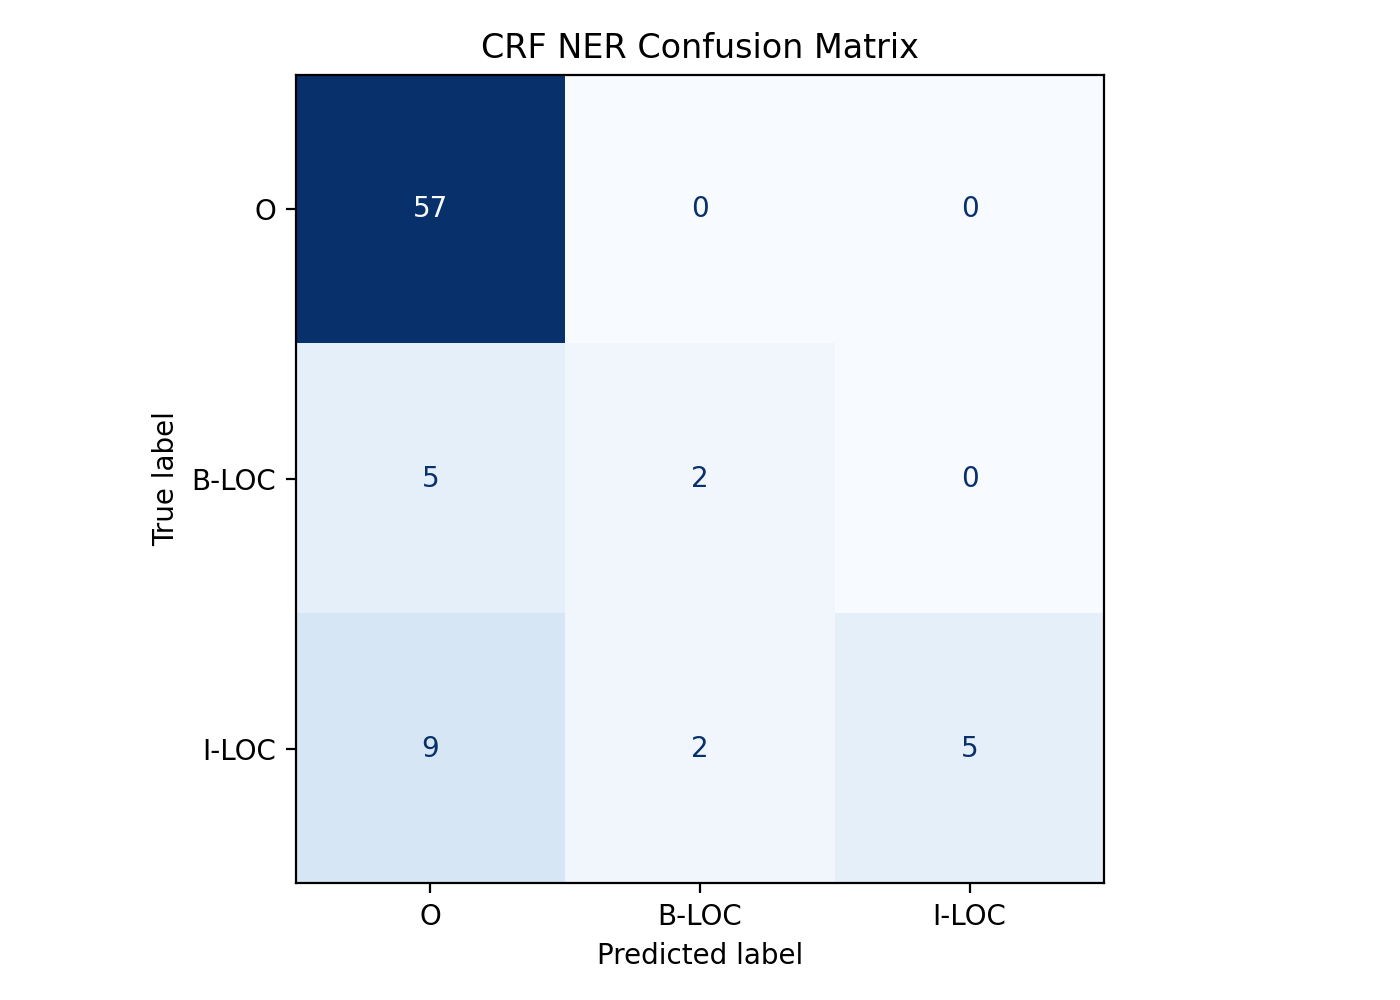

In [ ]:
results = train_pipeline(
    dataset_path=DATASET_PATH,
    gazetteer_path=GAZETTEER_PATH,
    output_dir=OUTPUT_DIR,
    augment_from_gazetteer=True,
    random_state=42,
)

print("Classification Report:")
print(results["evaluation"]["classification_report"])
print(f"Accuracy: {results['evaluation']['accuracy']:.4f}")
print(f"Model saved to: {results['model_path']}")
print(f"Confusion matrix saved to: {results['evaluation']['confusion_matrix_path']}")

if Image is not None:
    display(Image(filename=str(results["evaluation"]["confusion_matrix_path"])))

## Check for Overfitting / Underfitting
Evaluates the model on both the training and validation splits to see if it is memorizing the data (overfitting) or failing to learn (underfitting).

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn_crfsuite import metrics as crf_metrics

def overfitting_report_full(
    model,
    dataset_path,
    gazetteer_path,
    *,
    augment_from_gazetteer=True,
    random_state=42,
    gap_warn=0.10,
    gap_severe=0.15,
):
    """Train vs hold-out + gold-only test (no gazetteer augment)."""
    gazetteer_names, gazetteer_tokens = load_gazetteer(str(gazetteer_path))
    base = parse_tsv_dataset(str(dataset_path))

    def split_and_score(sentences, label):
        tr, te = train_test_split(sentences, test_size=0.2, random_state=random_state, shuffle=True)
        X_tr, y_tr = build_feature_matrices(tr, gazetteer_names, gazetteer_tokens)
        X_te, y_te = build_feature_matrices(te, gazetteer_names, gazetteer_tokens)
        y_tr_pred = model.predict(X_tr)
        y_te_pred = model.predict(X_te)
        train_f1 = crf_metrics.flat_f1_score(y_tr, y_tr_pred, average="weighted", labels=["B-LOC", "I-LOC"])
        test_f1 = crf_metrics.flat_f1_score(y_te, y_te_pred, average="weighted", labels=["B-LOC", "I-LOC"])
        print(f"\n--- {label} ---")
        print(f"  Train F1 (B/I-LOC): {train_f1:.4f}")
        print(f"  Hold-out F1:        {test_f1:.4f}")
        print(f"  Gap (train - test): {train_f1 - test_f1:.4f}")
        return train_f1, test_f1

    # A) Same as your current checker (augmented)
    aug = augment_with_gazetteer(base, gazetteer_names, random_state=random_state) if augment_from_gazetteer else base
    t_aug, v_aug = split_and_score(aug, "Augmented corpus (80/20)")

    # B) Gold-only — stricter generalization signal
    t_gold, v_gold = split_and_score(base, "Gold TSV only (no augment)")

    gap = t_aug - v_aug
    print("\n=== VERDICT (augmented split) ===")
    if gap >= gap_severe and v_aug < 0.85:
        print("Likely OVERFITTING (large gap, moderate/low validation F1).")
    elif gap >= gap_warn:
        print("Mild overfitting or high variance — try stronger c1/c2 or K-fold.")
    elif t_aug < 0.75 and v_aug < 0.75:
        print("Possible UNDERFITTING.")
    else:
        print("Acceptable train/validation balance on this split.")

    return {"train_f1_aug": t_aug, "val_f1_aug": v_aug, "train_f1_gold": t_gold, "val_f1_gold": v_gold}


def crf_kfold_overfitting_check(
    dataset_path,
    gazetteer_path,
    *,
    n_splits=5,
    augment_from_gazetteer=True,
    random_state=42,
    c1=0.1,
    c2=0.1,
):
    """Retrain per fold; mean train/val F1 shows stability (better for small data)."""
    gazetteer_names, gazetteer_tokens = load_gazetteer(str(gazetteer_path))
    sentences = parse_tsv_dataset(str(dataset_path))
    if augment_from_gazetteer:
        sentences = augment_with_gazetteer(sentences, gazetteer_names, random_state=random_state)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    train_scores, val_scores = [], []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(sentences), 1):
        tr = [sentences[i] for i in tr_idx]
        va = [sentences[i] for i in va_idx]
        X_tr, y_tr = build_feature_matrices(tr, gazetteer_names, gazetteer_tokens)
        X_va, y_va = build_feature_matrices(va, gazetteer_names, gazetteer_tokens)
        m = train_crf(X_tr, y_tr, c1=c1, c2=c2)
        y_tr_p = m.predict(X_tr)
        y_va_p = m.predict(X_va)
        train_scores.append(crf_metrics.flat_f1_score(y_tr, y_tr_p, average="weighted", labels=["B-LOC", "I-LOC"]))
        val_scores.append(crf_metrics.flat_f1_score(y_va, y_va_p, average="weighted", labels=["B-LOC", "I-LOC"]))
        print(f"Fold {fold}: train F1={train_scores[-1]:.4f}, val F1={val_scores[-1]:.4f}, gap={train_scores[-1]-val_scores[-1]:.4f}")

    print(f"\nMean train F1: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
    print(f"Mean val F1:   {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")
    print(f"Mean gap:      {np.mean(train_scores)-np.mean(val_scores):.4f}")
    if np.mean(train_scores) - np.mean(val_scores) > 0.12:
        print("K-fold suggests overfitting or high variance.")
    else:
        print("K-fold suggests reasonable generalization on this corpus.")

# Run the full report
overfitting_report_full(results["model"], DATASET_PATH, GAZETTEER_PATH)
# To run k-fold (slower but more robust), uncomment the line below:
# crf_kfold_overfitting_check(DATASET_PATH, GAZETTEER_PATH)


## 10. Run Inference on Example Queries

This final section tests the trained model on sample player questions.

## 10A. Resolver Acceptance Checks

This section runs focused resolver checks for alias handling, typo tolerance, noisy spans, and ambiguous place names while keeping the debug prints visible.

In [266]:
def print_query_resolution(query_text: str, title: str) -> None:
    resolution = resolve_query_locations(
        query_text,
        results["model"],
        results["gazetteer_names"],
        results["gazetteer_tokens"],
    )

    print(f"\n{title} before inference:", resolution["query"])
    print(f"{title} after tokenization:", resolution["tokens"])
    print(f"{title} CRF tags:", resolution["crf_tags"])
    print(f"{title} exact gazetteer matches:", resolution["exact_matches"])
    print(f"{title} alias matches:", resolution["alias_matches"])
    print(f"{title} fallback token spans:", resolution["fallback_token_spans"])
    print(f"{title} CRF spans:", resolution["crf_spans"])
    print(f"{title} structured entities:")
    for entity in resolution["entities"]:
        print(entity)
        if entity["fuzzy_corrections"]:
            print("  fuzzy corrections:", entity["fuzzy_corrections"])
        print("  overlap candidates + scores:", entity["candidates"])
    print(f"{title} extracted locations:", resolution["resolved_names"])

# ==========================================================
# 1. EXACT MATCHES (Nama Resmi / Sesuai Gazetteer)
# Menguji apakah model mengenali nama baku tanpa perlu alias.
# ==========================================================
print_query_resolution("How to unlock Mondstadt City?", "Exact Match - Simple")
print_query_resolution("Where is The Mausoleum of King Deshret?", "Exact Match - Long Name")
print_query_resolution("How do I get to Central Laboratory Ruins?", "Exact Match - Medium Name")

# ==========================================================
# 2. ALIAS MATCHES (Menggunakan ALIAS_MAP)
# Menguji apakah singkatan dari komunitas berhasil di-mapping ke nama asli.
# ==========================================================
print_query_resolution("how to unlock fri in fontaine?", "Alias Match - Acronym (FRI)")
print_query_resolution("how to go to enka", "Alias Match - Shortened (Enka)")
print_query_resolution("is there a quest for the prison?", "Alias Match - Slang (Prison)")
print_query_resolution("how to enter chasm underground", "Alias Match - Phrasing")
print_query_resolution("guide to unlock nodkrai", "Alias Match - Missing Hyphen")

# ==========================================================
# 3. NOISY & TYPOS (Fuzzy Matching Targets)
# Menguji ketahanan sistem terhadap salah ketik (typo) yang wajar terjadi di Discord.
# ==========================================================
print_query_resolution("how do i reach monstat?", "Typo - Missing letters (Monstat)")
print_query_resolution("unlock fontain research institut", "Typo - Missing 'e' (Fontaine)")
print_query_resolution("where is sumru desert", "Typo - Missing 'e' (Sumeru)")
print_query_resolution("how to enter the piramid", "Typo - 'i' instead of 'y' (Pyramid)")

# ==========================================================
# 4. MULTI-ENTITY QUERIES (Lebih dari 1 Lokasi dalam 1 Chat)
# Menguji apakah CRF bisa men-stabilo lebih dari satu entitas dalam satu kalimat.
# ==========================================================
print_query_resolution("is there a quest connecting liyue harbor and watatsumi island?", "Multi-Entity - Clean")
print_query_resolution("route from mond to liyue", "Multi-Entity - With Alias")
print_query_resolution("How do I enter Mt. Aocang and The Chasm: Underground Mines?", "Multi-Entity - Canonical")
print_query_resolution("difference between vanarana and old vanarana", "Multi-Entity - Overlapping words")

# ==========================================================
# 5. EDGE CASES (Tanda Baca Kritis: Kutip, Hubung, Apostrof)
# Ini ujian sesungguhnya untuk Tokenizer kamu (sesuai instruksi Cursor sebelumnya).
# ==========================================================
print_query_resolution("where is stormterror's lair?", "Edge Case - Apostrophe Possession")
print_query_resolution("how to get to clink-clank krumkake craftshop", "Edge Case - Hyphens")
print_query_resolution("go to mt. yougou", "Edge Case - Period / Abbreviation")
print_query_resolution("unlocking the children of echoes tribe", "Edge Case - Missing Quotes from Natlan")
print_query_resolution("is chemin de l'espoir locked?", "Edge Case - French Apostrophe")

# ==========================================================
# 6. AMBIGUOUS / EXTREME NOISE (Tantangan Ekstrem)
# ==========================================================
print_query_resolution("chasm", "Ambiguous - Single word")
print_query_resolution("how access underground mines in chasm bro pls help", "Extreme Noise - Reversed & Filler Words")

# ==========================================================
# 7. RANDOM & ADVANCED NOISE (Simulasi Chat Discord Asli)
# Menguji ketahanan model terhadap singkatan ekstrim, kata campur, dan konteks aneh.
# ==========================================================
print_query_resolution("is there a teleporter near dornman port", "Random - Newly Released Area")
print_query_resolution("bro how tf do i get inside the big ass pyramid", "Random - Extreme Slang (Pyramid Alias)")
print_query_resolution("can someone carry me in dat narukami shrine domain", "Random - Contextual Noise ('domain')")
print_query_resolution("what quest to unlock seiraimaru boat", "Random - Subarea with descriptive noun ('boat')")
print_query_resolution("where is qingce village man i cant find it", "Random - Frustrated User Text")
print_query_resolution("unlocking the ancient sacred mountain fast", "Random - Trailing Adverb ('fast')")

# ==========================================================
# 8. MULTI-REGION & CONFLICTING WORDS (Tantangan Parsing)
# Menguji apakah model bisa membedakan nama area yang punya kata mirip tapi beda region.
# ==========================================================
print_query_resolution("from mondstat to the chasm maw", "Multi-Region - Typo + Exact")
print_query_resolution("is the dune of magma harder than the dune of elusion", "Comparison - Same prefix 'the dune of'")
print_query_resolution("i hate exploring dragonspine and dragon spine", "Repetition & Spacing Test")
print_query_resolution("where do i find the scions of the canopy and masters of the night-wind", "Multi-Tribe - Natlan Extreme Quotes")
print_query_resolution("how to go from liyue city to sumeru city", "Multi-Entity - 'City' Suffix Match")

# ==========================================================
# 9. PUNCTUATION NIGHTMARES (Ujian Regex & Tokenizer Ekstrem)
# ==========================================================
print_query_resolution("how to enter [the chasm: underground mines]", "Punctuation - Bracketed Input")
print_query_resolution("go to... mt. aocang... then to... mt. hulao", "Punctuation - Ellipses (...) Noise")
print_query_resolution("unlock \"people of the springs\" please!!!", "Punctuation - Excessive Exclamation")
print_query_resolution("is qusayr al-inkhida' hard to explore?", "Punctuation - Trailing Apostrophe Mid-Sentence")
print_query_resolution("guide for chenyu vale: upper vale", "Punctuation - Colon without 'The Chasm'")

# ==========================================================
# 10. SHORT FRAGMENTS & KEYWORD ONLY (Pencarian Malas)
# ==========================================================
print_query_resolution("unlock court of fontaine", "Fragment - Verb + Location")
print_query_resolution("way to dadaupa gorge", "Fragment - Slang phrase")
print_query_resolution("farakhkert unlock", "Fragment - Reversed Verb")
print_query_resolution("how stadium of the sacred flame", "Fragment - Broken Grammar")


Exact Match - Simple before inference: How to unlock Mondstadt City?
Exact Match - Simple after tokenization: ['How', 'to', 'unlock', 'Mondstadt', 'City']
Exact Match - Simple CRF tags: [('How', 'O'), ('to', 'O'), ('unlock', 'O'), ('Mondstadt', 'B-LOC'), ('City', 'I-LOC')]
Exact Match - Simple exact gazetteer matches: ['mondstadt city']
Exact Match - Simple alias matches: []
Exact Match - Simple fallback token spans: []
Exact Match - Simple CRF spans: ['mondstadt city']
Exact Match - Simple structured entities:
{'raw_span': 'mondstadt city', 'resolved_name': 'mondstadt city', 'method': 'exact', 'confidence': 1.0, 'ambiguous': False, 'candidates': [{'name': 'mondstadt city', 'score': 1.0, 'reason': 'Matched exact canonical gazetteer phrase.'}], 'fuzzy_corrections': []}
  overlap candidates + scores: [{'name': 'mondstadt city', 'score': 1.0, 'reason': 'Matched exact canonical gazetteer phrase.'}]
Exact Match - Simple extracted locations: ['mondstadt city']

Exact Match - Long Name befor

In [267]:
print_query_resolution("I can't enter chsm, how do i do that?", "Pertanyaan Random")
print_query_resolution("I can't enter liyeu, how do i do that?", "Pertanyaan Random")


Pertanyaan Random before inference: I can't enter chsm, how do i do that?
Pertanyaan Random after tokenization: ['I', "can't", 'enter', 'chsm', 'how', 'do', 'i', 'do', 'that']
Pertanyaan Random CRF tags: [('I', 'O'), ("can't", 'O'), ('enter', 'O'), ('chsm', 'O'), ('how', 'O'), ('do', 'O'), ('i', 'O'), ('do', 'O'), ('that', 'O')]
Pertanyaan Random exact gazetteer matches: []
Pertanyaan Random alias matches: []
Pertanyaan Random fallback token spans: ['chsm']
Pertanyaan Random CRF spans: []
Pertanyaan Random structured entities:
{'raw_span': 'chsm', 'resolved_name': 'the chasm', 'method': 'fuzzy_overlap', 'confidence': 0.9, 'ambiguous': False, 'candidates': [{'name': 'the chasm', 'score': 0.9, 'reason': 'Resolved after fuzzy token correction and alias lookup.'}], 'fuzzy_corrections': [{'original': 'chsm', 'corrected': 'chasm', 'distance': 1, 'reason': "Corrected token 'chsm' to 'chasm' with edit distance 1."}]}
  fuzzy corrections: [{'original': 'chsm', 'corrected': 'chasm', 'distance':

## 11. Advanced Overfitting Checker (Added via Agent)

This cell contains the advanced overfitting checks (Gold TSV + K-Fold cross validation).

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn_crfsuite import metrics as crf_metrics

def overfitting_report_full(
    model,
    dataset_path,
    gazetteer_path,
    *,
    augment_from_gazetteer=True,
    random_state=42,
    gap_warn=0.10,
    gap_severe=0.15,
):
    """Train vs hold-out + gold-only test (no gazetteer augment)."""
    gazetteer_names, gazetteer_tokens = load_gazetteer(str(gazetteer_path))
    base = parse_tsv_dataset(str(dataset_path))

    def split_and_score(sentences, label):
        tr, te = train_test_split(sentences, test_size=0.2, random_state=random_state, shuffle=True)
        X_tr, y_tr = build_feature_matrices(tr, gazetteer_names, gazetteer_tokens)
        X_te, y_te = build_feature_matrices(te, gazetteer_names, gazetteer_tokens)
        y_tr_pred = model.predict(X_tr)
        y_te_pred = model.predict(X_te)
        train_f1 = crf_metrics.flat_f1_score(y_tr, y_tr_pred, average="weighted", labels=["B-LOC", "I-LOC"])
        test_f1 = crf_metrics.flat_f1_score(y_te, y_te_pred, average="weighted", labels=["B-LOC", "I-LOC"])
        print(f"\n--- {label} ---")
        print(f"  Train F1 (B/I-LOC): {train_f1:.4f}")
        print(f"  Hold-out F1:        {test_f1:.4f}")
        print(f"  Gap (train - test): {train_f1 - test_f1:.4f}")
        return train_f1, test_f1

    # A) Same as your current checker (augmented)
    aug = augment_with_gazetteer(base, gazetteer_names, random_state=random_state) if augment_from_gazetteer else base
    t_aug, v_aug = split_and_score(aug, "Augmented corpus (80/20)")

    # B) Gold-only — stricter generalization signal
    t_gold, v_gold = split_and_score(base, "Gold TSV only (no augment)")

    gap = t_aug - v_aug
    print("\n=== VERDICT (augmented split) ===")
    if gap >= gap_severe and v_aug < 0.85:
        print("Likely OVERFITTING (large gap, moderate/low validation F1).")
    elif gap >= gap_warn:
        print("Mild overfitting or high variance — try stronger c1/c2 or K-fold.")
    elif t_aug < 0.75 and v_aug < 0.75:
        print("Possible UNDERFITTING.")
    else:
        print("Acceptable train/validation balance on this split.")

    return {"train_f1_aug": t_aug, "val_f1_aug": v_aug, "train_f1_gold": t_gold, "val_f1_gold": v_gold}


def crf_kfold_overfitting_check(
    dataset_path,
    gazetteer_path,
    *,
    n_splits=5,
    augment_from_gazetteer=True,
    random_state=42,
    c1=0.1,
    c2=0.1,
):
    """Retrain per fold; mean train/val F1 shows stability (better for small data)."""
    gazetteer_names, gazetteer_tokens = load_gazetteer(str(gazetteer_path))
    sentences = parse_tsv_dataset(str(dataset_path))
    if augment_from_gazetteer:
        sentences = augment_with_gazetteer(sentences, gazetteer_names, random_state=random_state)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    train_scores, val_scores = [], []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(sentences), 1):
        tr = [sentences[i] for i in tr_idx]
        va = [sentences[i] for i in va_idx]
        X_tr, y_tr = build_feature_matrices(tr, gazetteer_names, gazetteer_tokens)
        X_va, y_va = build_feature_matrices(va, gazetteer_names, gazetteer_tokens)
        m = train_crf(X_tr, y_tr, c1=c1, c2=c2)
        y_tr_p = m.predict(X_tr)
        y_va_p = m.predict(X_va)
        train_scores.append(crf_metrics.flat_f1_score(y_tr, y_tr_p, average="weighted", labels=["B-LOC", "I-LOC"]))
        val_scores.append(crf_metrics.flat_f1_score(y_va, y_va_p, average="weighted", labels=["B-LOC", "I-LOC"]))
        print(f"Fold {fold}: train F1={train_scores[-1]:.4f}, val F1={val_scores[-1]:.4f}, gap={train_scores[-1]-val_scores[-1]:.4f}")

    print(f"\nMean train F1: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
    print(f"Mean val F1:   {np.mean(val_scores):.4f} ± {np.std(val_scores):.4f}")
    print(f"Mean gap:      {np.mean(train_scores)-np.mean(val_scores):.4f}")
    if np.mean(train_scores) - np.mean(val_scores) > 0.12:
        print("K-fold suggests overfitting or high variance.")
    else:
        print("K-fold suggests reasonable generalization on this corpus.")

# Run the full report
overfitting_report_full(results["model"], DATASET_PATH, GAZETTEER_PATH)
# To run k-fold (slower but more robust), uncomment the line below:
# crf_kfold_overfitting_check(DATASET_PATH, GAZETTEER_PATH)